 Customer Churn Prediction

In [2]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv(r"C:\Users\HP\Desktop\retailpulse_project\data\processed\cleaned_data.csv")

# Convert date column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Check data
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [3]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)


customer_df = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()

customer_df.columns = [
    'CustomerID',
    'Recency',
    'Frequency',
    'Monetary'
]

customer_df.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [4]:
# churn label

customer_df['Churn'] = np.where(
    customer_df['Recency'] > 90,
    1,
    0
)

customer_df['Churn'].value_counts()

Churn
0    2889
1    1449
Name: count, dtype: int64

In [5]:
customer_df.head()

,CustomerID,Recency,Frequency,Monetary,Churn
0,12346.0,326,1,77183.60,1
1,12347.0,2,7,4310.00,0
2,12348.0,75,4,1797.24,0
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,1


In [6]:
customer_df['Churn'].value_counts()

Churn
0    2889
1    1449
Name: count, dtype: int64

In [7]:
customer_df['Churn'].value_counts(normalize=True) * 100

Churn
0    66.59751
1    33.40249
Name: proportion, dtype: float64

In [8]:
# test and train split

from sklearn.model_selection import train_test_split

# Features and Target
X = customer_df[['Recency', 'Frequency', 'Monetary']]
y = customer_df['Churn']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 3470
Testing samples: 868


In [9]:
from xgboost import XGBClassifier

# Create model
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)

# Train
xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [10]:
import joblib


In [11]:
joblib.dump(xgb_model, "../models/churn_model.pkl")

print("Churn model saved successfully!")

Churn model saved successfully!


In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)


y_pred = xgb_model.predict(X_test)

y_prob = xgb_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC-AUC  : 1.0


In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       578
           1       1.00      1.00      1.00       290

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868



<Figure size 800x600 with 0 Axes>

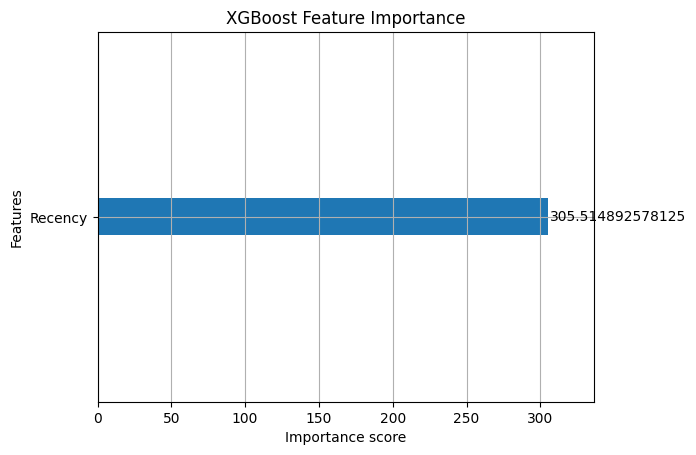

In [14]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plot_importance(
    xgb_model,
    importance_type='gain'
)

plt.title("XGBoost Feature Importance")
plt.show()

In [15]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

feature_importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
0,Recency,1.0
1,Frequency,0.0
2,Monetary,0.0


In [16]:
import shap
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

print("SHAP values generated successfully!")

SHAP values generated successfully!


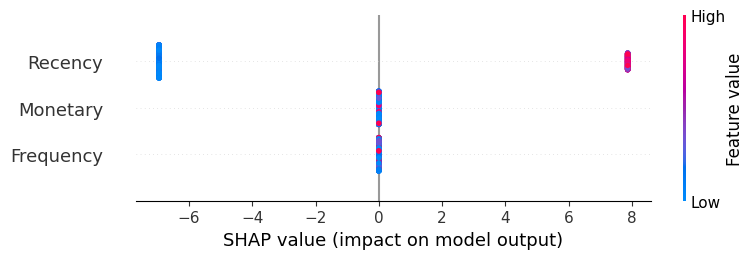

In [17]:
# summary plot

shap.summary_plot(
    shap_values,
    X_test
)

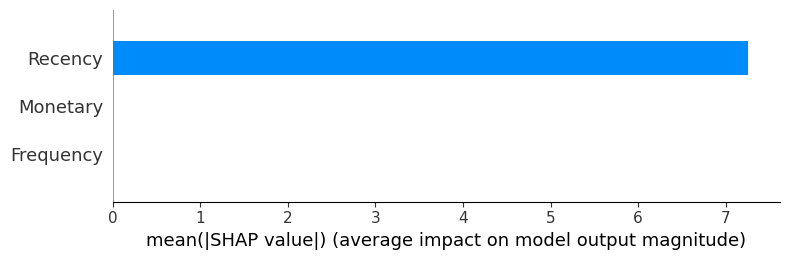

In [18]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

## SHAP Explainability

SHAP was used to explain the XGBoost churn prediction model.
